# A/B Test Analysis - Main Analysis

**Objective:** Analyze e-commerce checkout button A/B test and determine if the new design improves conversion.

**Author:** Ashish Patel  
**Date:** 2026-05-26

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# Load data
df = pd.read_csv('../data/sample/ab_test_data.csv')
print(f'✅ Loaded {len(df):,} users')
df.head()

✅ Loaded 100,000 users


,user_id,timestamp,variant,converted,revenue,device,new_user
0,t025722,2024-01-19 17:18:26.652009,treatment,1,74.73,desktop,1
1,t030185,2024-01-29 16:56:37.676835,treatment,0,0.00,desktop,1
2,c019865,2024-01-16 23:36:41.898980,control,0,0.00,mobile,1
3,t026700,2024-01-22 20:26:20.975523,treatment,0,0.00,tablet,1
4,t042992,2024-01-19 11:21:25.566799,treatment,0,0.00,desktop,0


## 2. Data Overview

In [3]:
print('📊 Test Overview')
print('=' * 50)
print(f"Total users: {len(df):,}")
print(f"\nGroup distribution:")
print(df['variant'].value_counts())

print(f"\nConversion by group:")
conversion = df.groupby('variant')['converted'].agg(['sum', 'count', 'mean'])
conversion.columns = ['Conversions', 'Users', 'Rate']
conversion['Rate'] = (conversion['Rate'] * 100).round(2)
print(conversion)

📊 Test Overview
Total users: 100,000

Group distribution:
variant
treatment    50000
control      50000
Name: count, dtype: int64

Conversion by group:
           Conversions  Users   Rate
variant                             
control           5421  50000  10.84
treatment         6396  50000  12.79


## 3. Statistical Test

In [4]:
# Extract group data
control = df[df['variant'] == 'control']
treatment = df[df['variant'] == 'treatment']

n_control = len(control)
n_treatment = len(treatment)
conv_control = control['converted'].sum()
conv_treatment = treatment['converted'].sum()

rate_control = conv_control / n_control
rate_treatment = conv_treatment / n_treatment

print(f'Control: {conv_control:,} / {n_control:,} = {rate_control:.4f} ({rate_control*100:.2f}%)')
print(f'Treatment: {conv_treatment:,} / {n_treatment:,} = {rate_treatment:.4f} ({rate_treatment*100:.2f}%)')
print(f'\nRelative lift: {(rate_treatment/rate_control - 1)*100:.2f}%')

Control: 5,421 / 50,000 = 0.1084 (10.84%)
Treatment: 6,396 / 50,000 = 0.1279 (12.79%)

Relative lift: 17.99%


In [5]:
# Two-proportion z-test
pooled_rate = (conv_control + conv_treatment) / (n_control + n_treatment)
se = np.sqrt(pooled_rate * (1 - pooled_rate) * (1/n_control + 1/n_treatment))
z_stat = (rate_treatment - rate_control) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print('📊 Two-Proportion Z-Test')
print('=' * 50)
print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print(f'\n✅ SIGNIFICANT at α={alpha}')
    print('   Reject null hypothesis: Treatment is different from Control')
else:
    print(f'\n❌ NOT SIGNIFICANT at α={alpha}')
    print('   Cannot reject null hypothesis')

📊 Two-Proportion Z-Test
Z-statistic: 9.5512
P-value: 0.000000

✅ SIGNIFICANT at α=0.05
   Reject null hypothesis: Treatment is different from Control


In [6]:
# Confidence interval
diff = rate_treatment - rate_control
se_diff = np.sqrt(rate_control*(1-rate_control)/n_control + rate_treatment*(1-rate_treatment)/n_treatment)
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print(f'\n📊 95% Confidence Interval for Difference:')
print(f'   [{ci_low*100:.2f}%, {ci_high*100:.2f}%]')

if ci_low > 0:
    print('   → Treatment is significantly BETTER')
elif ci_high < 0:
    print('   → Treatment is significantly WORSE')
else:
    print('   → No significant difference (CI includes 0)')


📊 95% Confidence Interval for Difference:
   [1.55%, 2.35%]
   → Treatment is significantly BETTER


## 4. Visualization

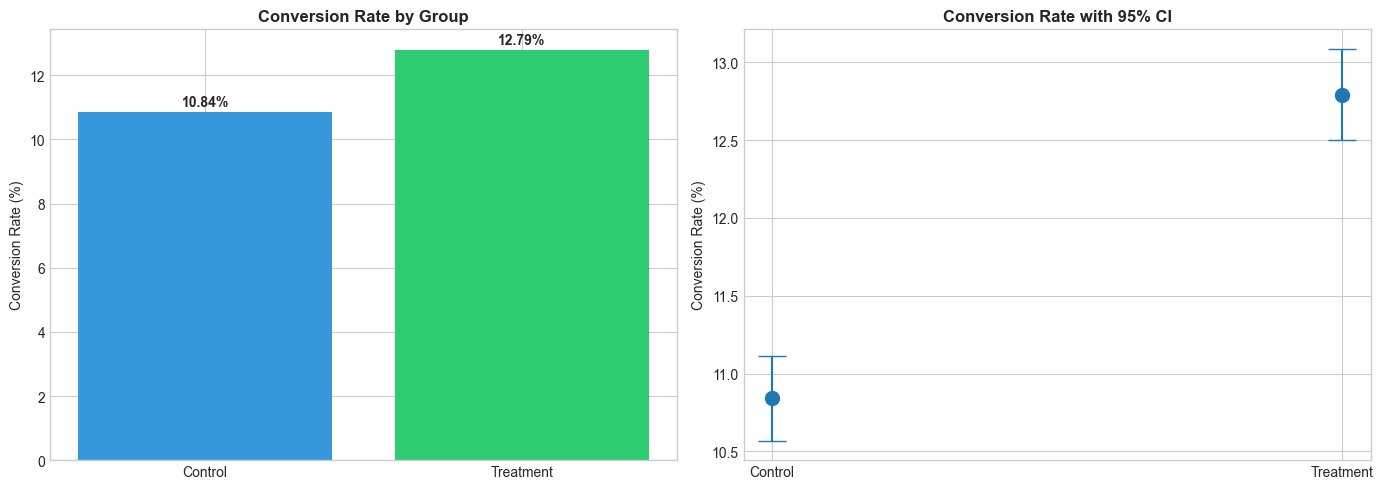

In [7]:
# Conversion rate comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
rates = [rate_control * 100, rate_treatment * 100]
colors = ['#3498db', '#2ecc71']
bars = axes[0].bar(['Control', 'Treatment'], rates, color=colors)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Group', fontweight='bold')
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{rate:.2f}%', ha='center', fontweight='bold')

# Error bar plot
errors = [1.96 * np.sqrt(rate_control*(1-rate_control)/n_control) * 100,
          1.96 * np.sqrt(rate_treatment*(1-rate_treatment)/n_treatment) * 100]
axes[1].errorbar(['Control', 'Treatment'], rates, yerr=errors, fmt='o', capsize=10, markersize=10)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Conversion Rate with 95% CI', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/img/ab_test_results.png', dpi=150)
plt.show()

## 5. Conclusion

In [8]:
print('=' * 60)
print('📊 A/B TEST CONCLUSION')
print('=' * 60)
print(f"""
TEST RESULTS:
• Control conversion: {rate_control*100:.2f}%
• Treatment conversion: {rate_treatment*100:.2f}%
• Relative lift: {(rate_treatment/rate_control - 1)*100:.2f}%
• P-value: {p_value:.6f}
• 95% CI: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]

RECOMMENDATION:
{'✅ SHIP IT: Treatment significantly outperforms Control' if p_value < 0.05 and rate_treatment > rate_control else '❌ DO NOT SHIP: No significant improvement detected'}

NEXT STEPS:
→ See 02_power_analysis.ipynb for sample size calculations
→ See 03_segmentation.ipynb for segment deep-dives
""")

📊 A/B TEST CONCLUSION

TEST RESULTS:
• Control conversion: 10.84%
• Treatment conversion: 12.79%
• Relative lift: 17.99%
• P-value: 0.000000
• 95% CI: [1.55%, 2.35%]

RECOMMENDATION:
✅ SHIP IT: Treatment significantly outperforms Control

NEXT STEPS:
→ See 02_power_analysis.ipynb for sample size calculations
→ See 03_segmentation.ipynb for segment deep-dives

